In [1]:
#Logistic Regression

#Unlike linear regression which predicts continuous values it predicts the probability that an input belongs to a specific class.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"framingham.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [4]:
df=df.dropna()
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4231,1,58,3.0,0,0.0,0.0,0,1,0,187.0,141.0,81.0,24.96,80.0,81.0,0
4232,1,68,1.0,0,0.0,0.0,0,1,0,176.0,168.0,97.0,23.14,60.0,79.0,1
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0


In [5]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  #it shuffles the dataset

In [6]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
X

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,-0.892997,-0.298768,0.019795,-0.978352,-0.757068,-0.176951,-0.076008,-0.672698,-0.166831,-0.314652,-0.559907,-0.744335,-1.356384,0.356340,-0.244956
1,-0.892997,-1.817466,0.019795,-0.978352,-0.757068,-0.176951,-0.076008,-0.672698,-0.166831,-1.516734,-0.514637,-0.744335,-1.221095,-0.728683,0.047847
2,-0.892997,2.037691,0.997773,1.022127,-0.673156,-0.176951,-0.076008,1.486551,-0.166831,0.116282,1.794161,0.090864,-1.469535,-0.478293,1.219059
3,-0.892997,-0.882882,0.019795,1.022127,-0.589244,-0.176951,-0.076008,-0.672698,-0.166831,-0.155887,-0.378825,-0.243215,-0.224872,1.190973,-0.203127
4,1.119825,-0.065122,0.019795,1.022127,3.438535,-0.176951,-0.076008,-0.672698,-0.166831,0.343090,1.069832,0.675504,-0.106801,-0.478293,1.344546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3651,1.119825,-1.350174,0.019795,1.022127,0.501613,-0.176951,-0.076008,-0.672698,-0.166831,-0.087845,0.209692,-0.660815,-1.287509,2.025606,1.051743
3652,-0.892997,0.986285,0.019795,1.022127,-0.505331,-0.176951,-0.076008,-0.672698,-0.166831,0.116282,-0.424096,-1.161935,-0.591384,-0.144440,-0.412272
3653,1.119825,-0.298768,1.975752,-0.978352,-0.757068,-0.176951,-0.076008,-0.672698,-0.166831,-0.972395,-0.786260,-0.076175,0.601624,-2.314486,-0.244956
3654,1.119825,0.402170,0.019795,-0.978352,-0.757068,-0.176951,-0.076008,-0.672698,-0.166831,0.864748,-1.057883,-0.326735,0.483553,-0.728683,0.926256


In [7]:
split_index = int(0.8 * len(X))
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [9]:
m, n = X_train.shape
weights = np.zeros(n)

In [10]:
learning_rate = 0.001
epochs = 5000

In [11]:
for i in range(epochs):
    
    z = np.dot(X_train, weights)       #This gives our (XW) used in our logistic regression
    predictions = sigmoid(z)

    gradient = (1/m) * np.dot(X_train.T, (predictions - y_train))    #Transverse bcz y and prediction are in the shape (m,) and the shape of X is (m,n)

    weights = weights - learning_rate * gradient

In [12]:
z_test = np.dot(X_test, weights)
y_pred = sigmoid(z_test)
y_pred = (y_pred >= 0.3).astype(int)

In [13]:
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

In [14]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

In [15]:
print("TP:", TP) 
print("TN:", TN)
print("FP:", FP) 
print("FN:", FN) 

TP: 58
TN: 451
FP: 177
FN: 46


In [16]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("Specificity:", specificity)
print("F1 Score:", f1_score)

Accuracy: 0.6953551912568307
Precision: 0.24680851063829787
Recall (Sensitivity): 0.5576923076923077
Specificity: 0.7181528662420382
F1 Score: 0.3421828908554572


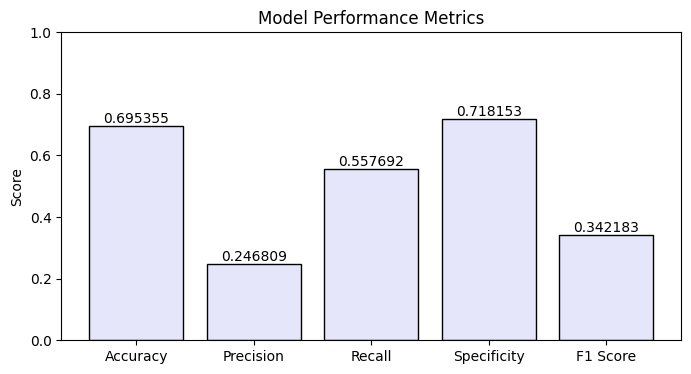

In [17]:
import matplotlib.pyplot as plt
metrics = ["Accuracy","Precision","Recall","Specificity","F1 Score"]
values = [accuracy, precision, recall, specificity, f1_score]

plt.figure(figsize=(8,4))
bar=plt.bar(metrics, values, color="lavender", edgecolor="black")
plt.bar_label(bar)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

In [ ]:
import seaborn as sns

cm = np.array([[TN, FP],
               [FN, TP]])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()